In [1]:
import pandas as pd
import numpy as np

In [2]:
cc=pd.read_excel(r"C:\Users\anadi\OneDrive\Desktop\BankCustomerData.xlsx")

In [3]:
cc.shape

(500, 10)

In [4]:
cc.head()

,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,France,Female,56,6,80919.81,2,Yes,No,27611.62,1
1,France,Female,69,4,106359.11,1,No,Yes,63450.98,1
2,Germany,Male,46,5,126902.59,2,No,No,122036.61,0
3,France,Male,32,6,60602.43,2,No,No,111998.52,0
4,Germany,Female,60,2,28709.21,1,Yes,No,122519.95,1


In [5]:
cc.tail()

,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
495,Germany,Male,65,9,234307.12,2,No,No,70632.65,0
496,Germany,Male,42,2,171971.43,2,Yes,No,70116.55,1
497,Germany,Female,57,4,16959.26,4,Yes,No,64250.32,1
498,Germany,Male,62,5,75240.89,3,Yes,Yes,90382.99,0
499,Germany,Male,18,9,177043.02,4,Yes,No,40038.86,0


In [6]:
cc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Geography        500 non-null    object 
 1   Gender           500 non-null    object 
 2   Age              500 non-null    int64  
 3   Tenure           500 non-null    int64  
 4   Balance          500 non-null    float64
 5   NumOfProducts    500 non-null    int64  
 6   HasCrCard        500 non-null    object 
 7   IsActiveMember   500 non-null    object 
 8   EstimatedSalary  500 non-null    float64
 9   Exited           500 non-null    int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 39.2+ KB


In [7]:
cc_cat=cc.select_dtypes(object)

In [8]:
cc_cat

,Geography,Gender,HasCrCard,IsActiveMember
0,France,Female,Yes,No
1,France,Female,No,Yes
2,Germany,Male,No,No
3,France,Male,No,No
4,Germany,Female,Yes,No
...,...,...,...,...
495,Germany,Male,No,No
496,Germany,Male,Yes,No
497,Germany,Female,Yes,No
498,Germany,Male,Yes,Yes


In [9]:
cc_cat_dummies=pd.get_dummies(cc_cat,drop_first=True)

In [10]:
cc_cat_dummies

,Geography_Germany,Geography_Spain,Gender_Male,HasCrCard_Yes,IsActiveMember_Yes
0,False,False,False,True,False
1,False,False,False,False,True
2,True,False,True,False,False
3,False,False,True,False,False
4,True,False,False,True,False
...,...,...,...,...,...
495,True,False,True,False,False
496,True,False,True,True,False
497,True,False,False,True,False
498,True,False,True,True,True


In [11]:
cc1 = pd.concat([cc,cc_cat_dummies], axis=1)

In [12]:
cc1

,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male,HasCrCard_Yes,IsActiveMember_Yes
0,France,Female,56,6,80919.81,2,Yes,No,27611.62,1,False,False,False,True,False
1,France,Female,69,4,106359.11,1,No,Yes,63450.98,1,False,False,False,False,True
2,Germany,Male,46,5,126902.59,2,No,No,122036.61,0,True,False,True,False,False
3,France,Male,32,6,60602.43,2,No,No,111998.52,0,False,False,True,False,False
4,Germany,Female,60,2,28709.21,1,Yes,No,122519.95,1,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Germany,Male,65,9,234307.12,2,No,No,70632.65,0,True,False,True,False,False
496,Germany,Male,42,2,171971.43,2,Yes,No,70116.55,1,True,False,True,True,False
497,Germany,Female,57,4,16959.26,4,Yes,No,64250.32,1,True,False,False,True,False
498,Germany,Male,62,5,75240.89,3,Yes,Yes,90382.99,0,True,False,True,True,True


In [13]:
cc2=cc1.drop(["Geography","Gender","HasCrCard","IsActiveMember"],axis="columns")

In [14]:
cc2

,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male,HasCrCard_Yes,IsActiveMember_Yes
0,56,6,80919.81,2,27611.62,1,False,False,False,True,False
1,69,4,106359.11,1,63450.98,1,False,False,False,False,True
2,46,5,126902.59,2,122036.61,0,True,False,True,False,False
3,32,6,60602.43,2,111998.52,0,False,False,True,False,False
4,60,2,28709.21,1,122519.95,1,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
495,65,9,234307.12,2,70632.65,0,True,False,True,False,False
496,42,2,171971.43,2,70116.55,1,True,False,True,True,False
497,57,4,16959.26,4,64250.32,1,True,False,False,True,False
498,62,5,75240.89,3,90382.99,0,True,False,True,True,True


In [15]:
y= cc2['Exited']

In [16]:
y

0      1
1      1
2      0
3      0
4      1
      ..
495    0
496    1
497    1
498    0
499    0
Name: Exited, Length: 500, dtype: int64

In [17]:
cc2.head()

,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male,HasCrCard_Yes,IsActiveMember_Yes
0,56,6,80919.81,2,27611.62,1,False,False,False,True,False
1,69,4,106359.11,1,63450.98,1,False,False,False,False,True
2,46,5,126902.59,2,122036.61,0,True,False,True,False,False
3,32,6,60602.43,2,111998.52,0,False,False,True,False,False
4,60,2,28709.21,1,122519.95,1,True,False,False,True,False


In [18]:
x=cc2[["Age","Tenure","Balance","NumOfProducts","EstimatedSalary","Geography_Germany","Geography_Spain","Gender_Male","HasCrCard_Yes","IsActiveMember_Yes"]]

In [19]:
x

,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male,HasCrCard_Yes,IsActiveMember_Yes
0,56,6,80919.81,2,27611.62,False,False,False,True,False
1,69,4,106359.11,1,63450.98,False,False,False,False,True
2,46,5,126902.59,2,122036.61,True,False,True,False,False
3,32,6,60602.43,2,111998.52,False,False,True,False,False
4,60,2,28709.21,1,122519.95,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...
495,65,9,234307.12,2,70632.65,True,False,True,False,False
496,42,2,171971.43,2,70116.55,True,False,True,True,False
497,57,4,16959.26,4,64250.32,True,False,False,True,False
498,62,5,75240.89,3,90382.99,True,False,True,True,True


In [20]:
import sklearn 

In [21]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=38)

In [22]:
xtrain.shape

(350, 10)

In [23]:
ytrain.shape

(350,)

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler=StandardScaler()

In [26]:
xtrain_scaled=scaler.fit_transform(xtrain)

In [27]:
xtest_scaled=scaler.transform(xtest)

In [28]:
from sklearn import linear_model

In [29]:
from sklearn.linear_model import LogisticRegression

In [30]:
log_reg=LogisticRegression()

In [31]:
log_reg.fit(xtrain_scaled,ytrain)

LogisticRegression()

In [32]:
ypred=log_reg.predict(xtest_scaled)

In [33]:
ypred

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0])

In [34]:
log_reg.score(xtrain_scaled,ytrain)

0.6628571428571428

In [35]:
log_reg.score(xtest_scaled,ytest)

0.66

In [36]:
import sklearn.metrics as metrics 

In [37]:
from sklearn.metrics import confusion_matrix

In [38]:
confusion_matrix(ytest,ypred)

array([[64, 20],
       [31, 35]])

In [39]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

In [40]:
ytrain_probs = log_reg.predict_proba(xtrain_scaled)[:, 1]
ytest_probs  = log_reg.predict_proba(xtest_scaled)[:, 1]

In [41]:
auc_train = roc_auc_score(ytrain, ytrain_probs)
auc_test  = roc_auc_score(ytest,  ytest_probs)

In [42]:
auc_train

np.float64(0.7349545078577336)

In [43]:
auc_test 

np.float64(0.6915584415584416)

In [44]:
fpr, tpr, thresholds = roc_curve(ytest, ytest_probs)

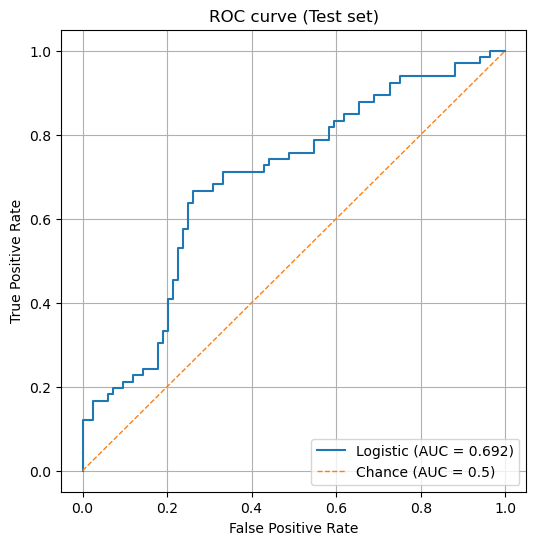

In [45]:
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'Logistic (AUC = {auc_test:.3f})')
plt.plot([0,1], [0,1], linestyle='--', linewidth=1, label='Chance (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve (Test set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [46]:
# After fitting your model (log_reg.fit(...))

# Get feature names (after dummies)
feature_names = xtrain.columns  

# Get coefficients
coefficients = log_reg.coef_[0]

# Convert to dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Importance (Abs)": np.abs(coefficients)
})

# Sort by absolute importance
feature_importance = feature_importance.sort_values(by="Importance (Abs)", ascending=False)

print(feature_importance)

              Feature  Coefficient  Importance (Abs)
9  IsActiveMember_Yes    -0.489902          0.489902
1              Tenure    -0.442810          0.442810
2             Balance    -0.395919          0.395919
3       NumOfProducts    -0.278358          0.278358
0                 Age     0.142470          0.142470
7         Gender_Male     0.069289          0.069289
4     EstimatedSalary     0.062237          0.062237
8       HasCrCard_Yes    -0.058793          0.058793
5   Geography_Germany    -0.017102          0.017102
6     Geography_Spain    -0.014298          0.014298


In [47]:
from sklearn.metrics import roc_curve

# Get ROC curve values
fpr, tpr, thresholds = roc_curve(ytest,  ytest_probs)

# Compute Youden's J statistic (sensitivity + specificity - 1)
j_scores = tpr - fpr
j_ordered = sorted(zip(j_scores, thresholds))
best_j, best_threshold = j_ordered[-1]

print(f"Best Threshold (Youden's J): {best_threshold:.3f}")
print(f"Max J Score: {best_j:.3f}")

Best Threshold (Youden's J): 0.455
Max J Score: 0.405


In [48]:
from sklearn.metrics import confusion_matrix

# --- Find optimal threshold ---
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal Threshold: {best_threshold:.3f}")

# --- Apply new threshold ---
y_pred_optimal = (ytest_probs >= best_threshold).astype(int)

# --- New confusion matrix ---
cm_optimal = confusion_matrix(ytest, y_pred_optimal)
print("Confusion Matrix at Optimal Threshold:\n", cm_optimal)

# --- Accuracy & Sensitivity ---
tn, fp, fn, tp = cm_optimal.ravel()

accuracy_optimal = (tp + tn) / (tp + tn + fp + fn)
sensitivity_optimal = tp / (tp + fn)

print(f"Accuracy at Optimal Threshold: {accuracy_optimal:.2f}")
print(f"Sensitivity at Optimal Threshold: {sensitivity_optimal:.2f}")

Optimal Threshold: 0.455
Confusion Matrix at Optimal Threshold:
 [[62 22]
 [22 44]]
Accuracy at Optimal Threshold: 0.71
Sensitivity at Optimal Threshold: 0.67


In [49]:
import numpy as np
from sklearn.metrics import roc_curve

# Get ROC curve values
fpr, tpr, thresholds = roc_curve(ytest, ytest_probs)

# Calculate slope differences (approximate curvature)
slopes = np.diff(tpr) / np.diff(fpr)

# Find points where slope changes sign (inflection points)
inflection_indices = np.where(np.diff(np.sign(np.diff(slopes))) != 0)[0]

# Number of inflection points
print("Number of inflection points:", len(inflection_indices))

# Thresholds at inflection points
print("Thresholds at inflection points:", thresholds[inflection_indices])

Number of inflection points: 61
Thresholds at inflection points: [       inf 0.83323237 0.72205173 0.71226442 0.6802237  0.65994433
 0.65635064 0.65497651 0.64844863 0.63693531 0.63352304 0.6267571
 0.62207301 0.61663831 0.61442599 0.60403368 0.59217976 0.59217126
 0.58891126 0.58209457 0.55319829 0.55314433 0.54306035 0.53534333
 0.51905696 0.50134692 0.49415312 0.48005977 0.4663075  0.46238721
 0.45516178 0.4413002  0.44055593 0.43889296 0.43215335 0.40646285
 0.40164167 0.39289745 0.38558429 0.37847026 0.37755883 0.36709559
 0.36486994 0.35008898 0.34633675 0.33722545 0.33297609 0.32647639
 0.3249632  0.30043664 0.28283213 0.26771108 0.2675721  0.25708269
 0.25020314 0.24551978 0.24533611 0.21051222 0.19199388 0.17229684
 0.16428616]


C:\Users\anadi\AppData\Local\Temp\ipykernel_15012\3175607667.py:8: RuntimeWarning: divide by zero encountered in divide
  slopes = np.diff(tpr) / np.diff(fpr)
C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:1515: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])


Naive bayes

In [50]:
from sklearn import naive_bayes
from sklearn.naive_bayes import GaussianNB

In [51]:
nb=GaussianNB()            
nb=nb.fit(xtrain,ytrain)  

In [52]:
y_pred=nb.predict(xtest)

In [53]:
nb.score(xtrain,ytrain)

0.6371428571428571

In [54]:
nb.score(xtest,ytest)

0.5466666666666666

In [55]:
import sklearn.metrics as metrics 
from sklearn.metrics import confusion_matrix

In [56]:
confusion_matrix(ytest,y_pred)

array([[59, 25],
       [43, 23]])

In [57]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [58]:
r_prob=[0 for _ in range(len(ytest))]
nb_prob= nb.predict_proba(xtest)
nb_prob1=nb_prob[:,1]

In [59]:
from sklearn.metrics import roc_auc_score

In [60]:
nb_auc=roc_auc_score(ytest,nb_prob1)

In [61]:
nb_auc

np.float64(0.5663780663780663)

In [62]:
nb_fpr, nb_tpr,_=roc_curve(ytest,nb_prob1)

In [63]:
def plot_roc_curve(nb_fpr,nb_tpr):
 plt.plot(nb_fpr,nb_tpr,marker=".")
 plt.xlabel("False Positive")
 plt.ylabel("True Positive Rate")
 plt.title("ROC Curve")
 plt.show() 

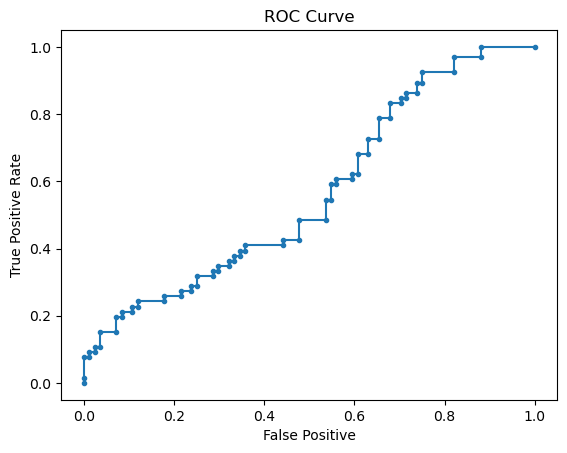

In [64]:
plot_roc_curve(nb_fpr,nb_tpr)

classification decision tree

In [65]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()            
dt=dt.fit(xtrain,ytrain)                                                                
y_pred=dt.predict(xtest)
y_pred

array([0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0])

In [66]:
from sklearn import tree
text_form=tree.export_text(dt) 

In [67]:
text_form

'|--- feature_2 <= 83467.88\n|   |--- feature_1 <= 6.50\n|   |   |--- feature_0 <= 24.50\n|   |   |   |--- feature_3 <= 2.50\n|   |   |   |   |--- class: 1\n|   |   |   |--- feature_3 >  2.50\n|   |   |   |   |--- feature_6 <= 0.50\n|   |   |   |   |   |--- class: 0\n|   |   |   |   |--- feature_6 >  0.50\n|   |   |   |   |   |--- feature_2 <= 13158.50\n|   |   |   |   |   |   |--- class: 0\n|   |   |   |   |   |--- feature_2 >  13158.50\n|   |   |   |   |   |   |--- class: 1\n|   |   |--- feature_0 >  24.50\n|   |   |   |--- feature_1 <= 2.50\n|   |   |   |   |--- feature_4 <= 137682.89\n|   |   |   |   |   |--- feature_6 <= 0.50\n|   |   |   |   |   |   |--- class: 1\n|   |   |   |   |   |--- feature_6 >  0.50\n|   |   |   |   |   |   |--- feature_7 <= 0.50\n|   |   |   |   |   |   |   |--- feature_3 <= 2.50\n|   |   |   |   |   |   |   |   |--- class: 1\n|   |   |   |   |   |   |   |--- feature_3 >  2.50\n|   |   |   |   |   |   |   |   |--- class: 0\n|   |   |   |   |   |   |--- fe

In [68]:
dt.score(xtrain,ytrain)

1.0

In [69]:
dt.score(xtest,ytest)

0.56

In [70]:
import sklearn.metrics as metrics
from sklearn.metrics import confusion_matrix

In [71]:
confusion_matrix(ytest,y_pred)

array([[56, 28],
       [38, 28]])

In [72]:
x.columns

Index(['Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary',
       'Geography_Germany', 'Geography_Spain', 'Gender_Male', 'HasCrCard_Yes',
       'IsActiveMember_Yes'],
      dtype='object')

In [73]:
features=pd.DataFrame(dt.feature_importances_,index=x.columns)

In [74]:
features

,0
Age,0.117843
Tenure,0.103380
Balance,0.277017
NumOfProducts,0.081391
EstimatedSalary,0.220677
Geography_Germany,0.026634
Geography_Spain,0.055986
Gender_Male,0.018013
HasCrCard_Yes,0.024628
IsActiveMember_Yes,0.074432


In [75]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt  
import seaborn as sns  

In [76]:
from sklearn.metrics import roc_auc_score

In [77]:
r_prob=[0 for _ in range(len(ytest))]
dt_prob= dt.predict_proba(xtest)
dt_prob1=dt_prob[:,1]

In [78]:
dt_auc=roc_auc_score(ytest,dt_prob1)

In [79]:
dt_auc

np.float64(0.5454545454545455)

In [80]:
dt_fpr, dt_tpr,_=roc_curve(ytest,dt_prob1)

In [81]:
def plot_roc_curve(dt_fpr,dt_tpr):
 plt.plot(dt_fpr,dt_tpr,marker=".")
 plt.xlabel("False Positive")
 plt.ylabel("True Positive Rate")
 plt.title("ROC Curve")
 plt.show()

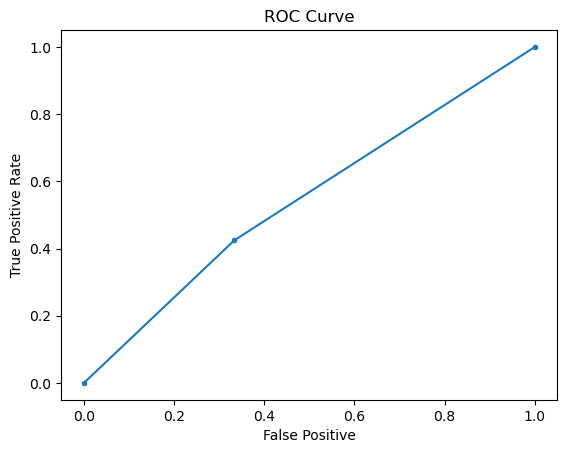

In [82]:
plot_roc_curve(dt_fpr,dt_tpr)

In [83]:
# RANDOM FOREST #

In [84]:
from sklearn.ensemble import RandomForestClassifier

In [85]:
rf=RandomForestClassifier(n_estimators=100)

In [86]:
rf=rf.fit(xtrain,ytrain)

In [87]:

y_pred=rf.predict(xtest)

In [88]:
rf.score(xtrain,ytrain)

1.0

In [89]:
rf.score(xtest,ytest)

0.6266666666666667

In [90]:
import sklearn.metrics as metrics 

In [91]:
from sklearn.metrics import confusion_matrix

In [92]:
confusion_matrix(ytest,y_pred)

array([[59, 25],
       [31, 35]])

In [93]:
x.columns

Index(['Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary',
       'Geography_Germany', 'Geography_Spain', 'Gender_Male', 'HasCrCard_Yes',
       'IsActiveMember_Yes'],
      dtype='object')

In [94]:
features=pd.DataFrame(rf.feature_importances_,index=x.columns)

In [95]:
features

,0
Age,0.180698
Tenure,0.152189
Balance,0.220290
NumOfProducts,0.074742
EstimatedSalary,0.184413
Geography_Germany,0.031952
Geography_Spain,0.030866
Gender_Male,0.029456
HasCrCard_Yes,0.035044
IsActiveMember_Yes,0.060349


In [96]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt 

In [97]:
from sklearn.metrics import roc_auc_score

In [98]:
r_prob=[0 for _ in range(len(ytest))]
rf_prob= rf.predict_proba(xtest)
rf_prob1=rf_prob[:,1]

In [99]:
rf_auc=roc_auc_score(ytest,rf_prob1)

In [100]:
rf_auc

np.float64(0.6521464646464646)

In [101]:
rf_fpr, rf_tpr,_=roc_curve(ytest,rf_prob1)

In [102]:
def plot_roc_curve(rf_fpr,rf_tpr):
 plt.plot(rf_fpr,rf_tpr,marker=".")
 plt.xlabel("False Positive")
 plt.ylabel("True Positive Rate")
 plt.title("ROC Curve")
 plt.show()

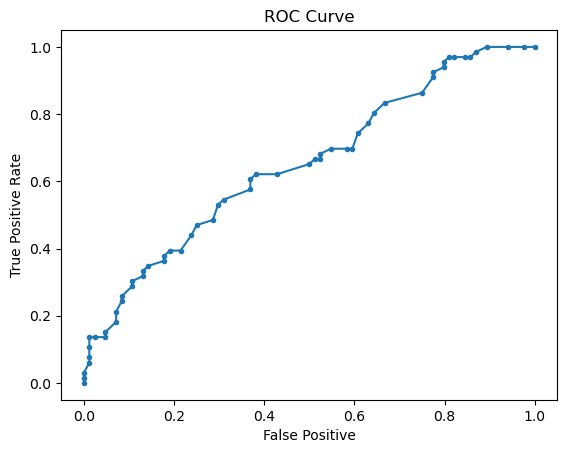

In [103]:
plot_roc_curve(rf_fpr,rf_tpr)

<BarContainer object of 10 artists>

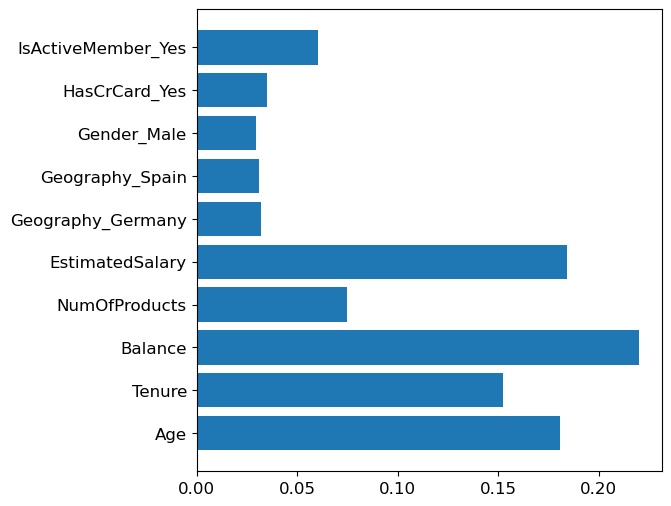

In [104]:
from matplotlib import pyplot as plt
plt.rcParams.update({"figure.figsize":(6,6)})
plt.rcParams.update({"font.size":12})
feature_names=x.columns 
plt.barh(feature_names, rf.feature_importances_)